# Working with complicated dataset

Your name: Anika Manjesh

HW Assignment 4

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [1]:
### Your code here . . .
import pandas as pd
blast_results_file = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

In [2]:
my_columns = ["query acc.ver", "subject acc.ver", "% identity",
              "alignment length", "mismatches", "gap opens", "q. start", "q. end",
              "s. start", "s. end", "evalue", "bit score", "% positives", "bonds",
              "publications"]
blast = pd.read_csv(blast_results_file,
                      names=my_columns,
                      usecols=my_columns,
                      # engine='python',
                      comment="#" # lines starts with # is considered
                     )            # comments.

In [3]:
blast.drop(columns="query acc.ver", inplace=True)
blast.set_index("subject acc.ver", inplace=True)
blast = blast.dropna()

In [4]:
blast.head(5)

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"1,487",9
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"17,947",47
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,"12,106",13
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,"2,319",41
AHG32084.1,99.371,318.0,2.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,"18,964",3


### Question 2
What is the average number of publications?

About 27 publications.

In [5]:
### Your code here . . .
blast['publications'] = pd.to_numeric(blast['publications'], errors ='coerce') # had an issue so added the error coerce portion
blast['publications'].mean()

np.float64(26.989690721649485)

### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [6]:
### Your code here . . .
blast['bonds'] = blast['bonds'].astype(str).str.replace(',', '').str.strip()
blast[pd.to_numeric(blast['bonds'], errors='coerce') > 15000]

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,17947,47.0
AHG32084.1,99.371,318.0,2.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,18964,3.0
6G2J_H,100.000,317.0,0.0,0.0,2.0,318.0,2.0,318.0,0.0,626.0,100.00,15663,29.0
YP_002791042.1,99.057,318.0,3.0,0.0,1.0,318.0,1.0,318.0,0.0,625.0,99.69,15830,37.0
AGK29634.1,99.057,318.0,3.0,0.0,1.0,318.0,1.0,318.0,0.0,623.0,99.69,17381,14.0
0806162F,100.000,315.0,0.0,0.0,4.0,318.0,1.0,315.0,0.0,622.0,100.00,17499,43.0
YP_009112408.1,97.170,318.0,9.0,0.0,1.0,318.0,1.0,318.0,0.0,615.0,99.37,16861,46.0
YP_001876469.1,96.855,318.0,10.0,0.0,1.0,318.0,1.0,318.0,0.0,613.0,99.06,16274,22.0
YP_009092269.1,96.226,318.0,12.0,0.0,1.0,318.0,1.0,318.0,0.0,610.0,98.11,16170,47.0


In [7]:
blast.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, NP_904328.1 to AGS12808.1
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   % identity        100 non-null    float64
 1   alignment length  100 non-null    float64
 2   mismatches        100 non-null    float64
 3   gap opens         100 non-null    float64
 4   q. start          100 non-null    float64
 5   q. end            100 non-null    float64
 6   s. start          100 non-null    float64
 7   s. end            100 non-null    float64
 8   evalue            100 non-null    float64
 9   bit score         100 non-null    float64
 10  % positives       100 non-null    float64
 11  bonds             100 non-null    object 
 12  publications      97 non-null     float64
dtypes: float64(12), object(1)
memory usage: 15.0+ KB


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

In [8]:
### Your code here . . .
import seaborn as sns
import matplotlib.pyplot as plt

<Figure size 1000x4000 with 0 Axes>

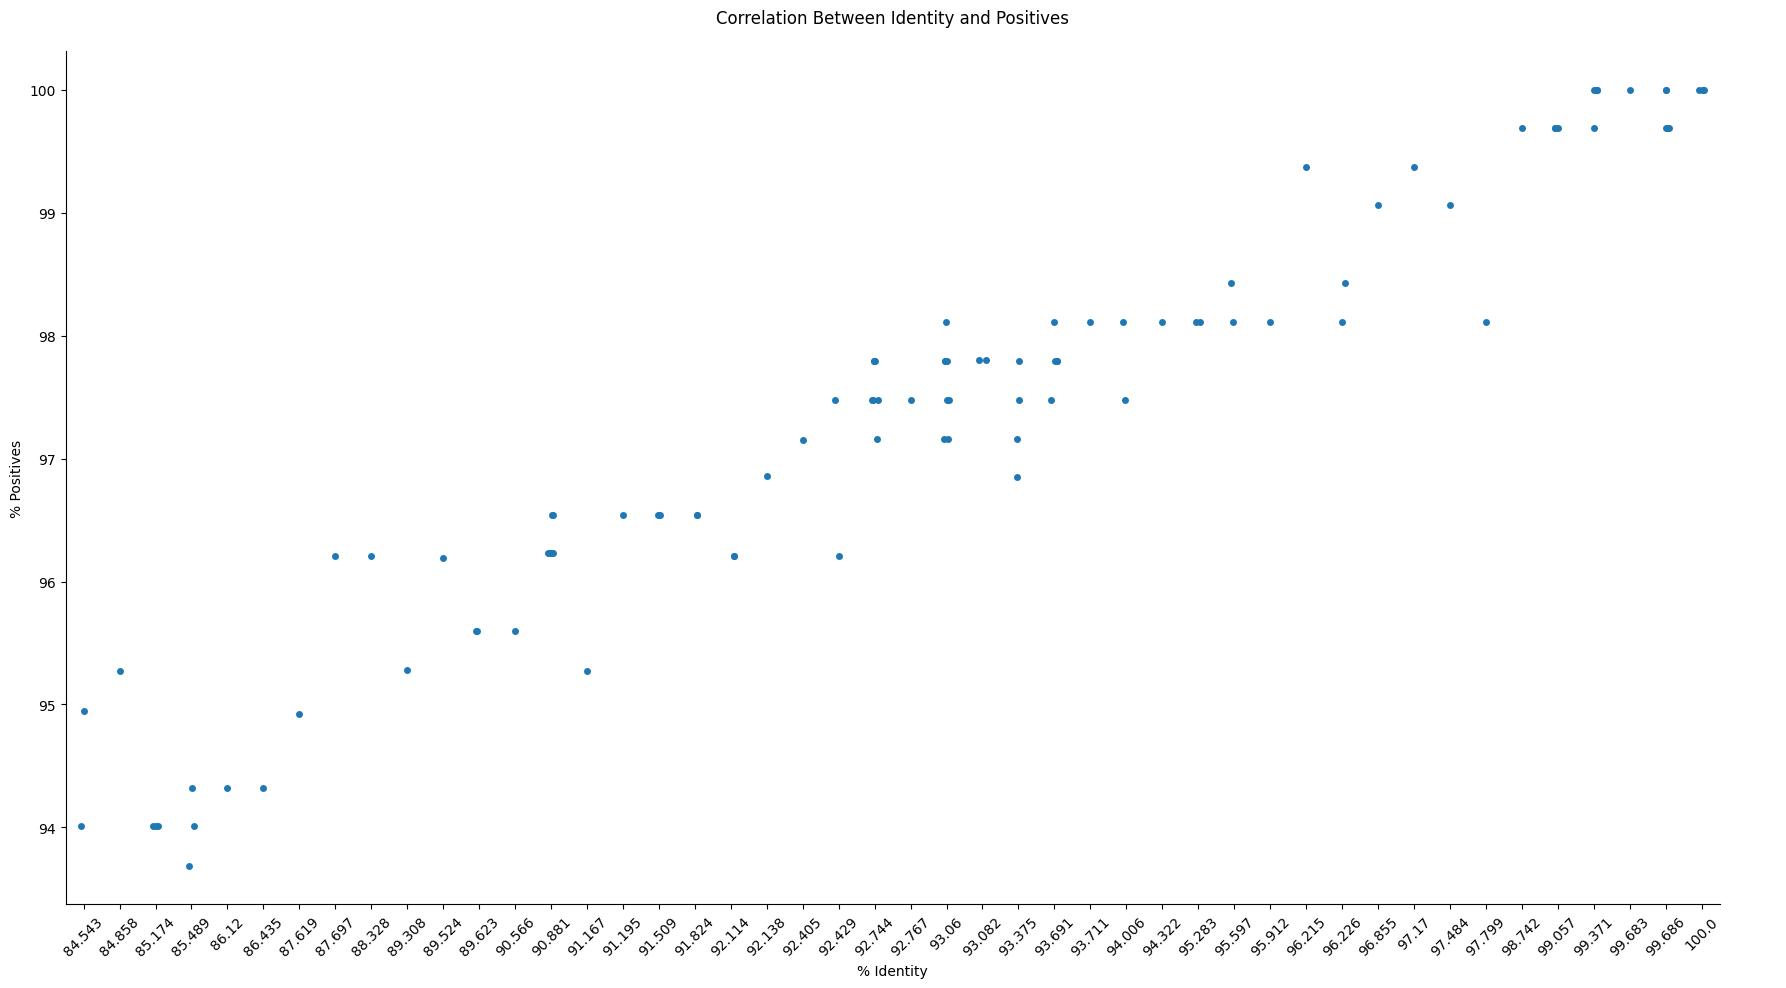

In [9]:
plt.figure(figsize=(10,40))
frame = sns.catplot(
    x = '% identity',
    y = '% positives',
    data = blast
    # kind = 'bar'
).set_axis_labels('% Identity','% Positives');
frame.fig.set_size_inches(20,10)
frame.set_xticklabels(rotation=45)
plt.title("Correlation Between Identity and Positives", pad=20);

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [10]:
### Your code here . . .
protein_file = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"

In [11]:
my_protein_columns = ["index","Protein", "Protein source"]
protein = pd.read_csv(protein_file,
                      names=my_protein_columns,
                      usecols=my_protein_columns,
                      skiprows=1
                     )


In [12]:
protein.head()

,index,Protein,Protein source
0,0,NP_904328.1,RefSeq
1,2,YP_220563.1,GenPept
2,12,YP_002791042.1,GenPept
3,13,YP_001686698.1,GenPept
4,21,YP_009112408.1,GenPept


In [13]:
protein.set_index('index')

,Protein,Protein source
index,,
0,NP_904328.1,RefSeq
2,YP_220563.1,GenPept
12,YP_002791042.1,GenPept
13,YP_001686698.1,GenPept
21,YP_009112408.1,GenPept
...,...,...
92,YP_009093743.1,GenPept
93,YP_665629.1,GenPept
94,YP_002381170.1,GenPept


In [14]:
protein.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   index           64 non-null     int64 
 1   Protein         64 non-null     object
 2   Protein source  64 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [15]:
# new_blast = blast.merge(protein, how="left", right_on="Protein", left_on="subject acc.ver")
new_blast = blast.merge(protein, how="left", right_on="Protein", left_index=True)
new_blast.set_index("Protein", inplace=True)
new_blast

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,index,Protein source
Protein,,,,,,,,,,,,,,,
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,1487,9.0,0.0,RefSeq
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,17947,47.0,NaN,NaN
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,12106,13.0,2.0,GenPept
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,2319,41.0,NaN,NaN
AHG32084.1,99.371,318.0,2.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,18964,3.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ABX45285.1,92.767,318.0,23.0,0.0,1.0,318.0,1.0,318.0,0.0,551.0,97.48,17348,6.0,NaN,NaN
ASP44815.1,93.375,317.0,21.0,0.0,1.0,317.0,1.0,317.0,0.0,551.0,96.85,7105,19.0,NaN,NaN
YP_009414156.1,84.543,317.0,49.0,0.0,1.0,317.0,1.0,317.0,0.0,551.0,94.01,18940,37.0,97.0,GenPept
